<a href="https://colab.research.google.com/github/yuya0426/Kaggle_Heart_Disease/blob/main/notebooks/%E5%BF%83%E8%87%93%E7%97%85%E4%BA%88%E6%B8%AC_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
import pandas as pd
from google.colab import userdata

# 1. ここをご自身の文字列に書き換えてください
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!kaggle competitions download -c playground-series-s6e2
!unzip -o playground-series-s6e2.zip

# 3. データを読み込み
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

playground-series-s6e2.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  playground-series-s6e2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null 

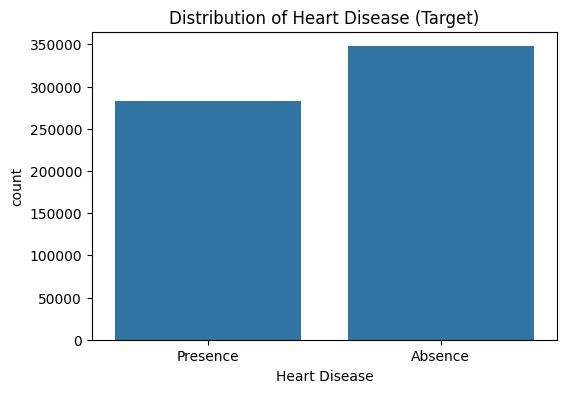

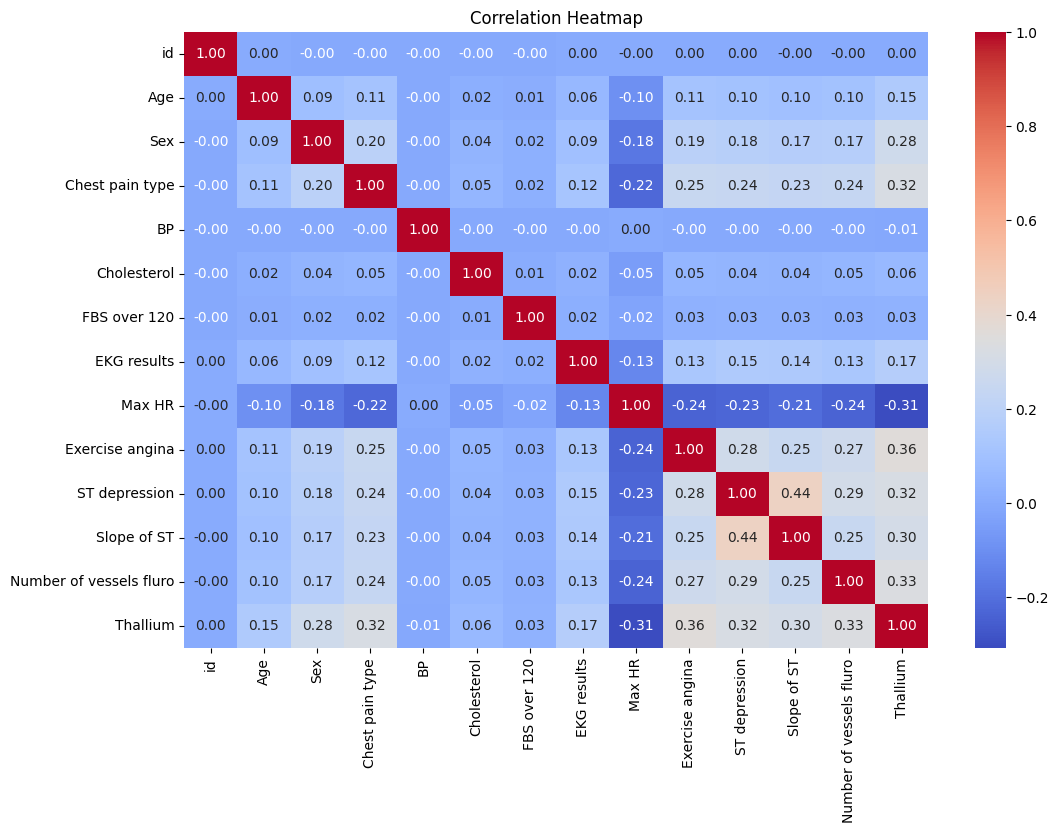

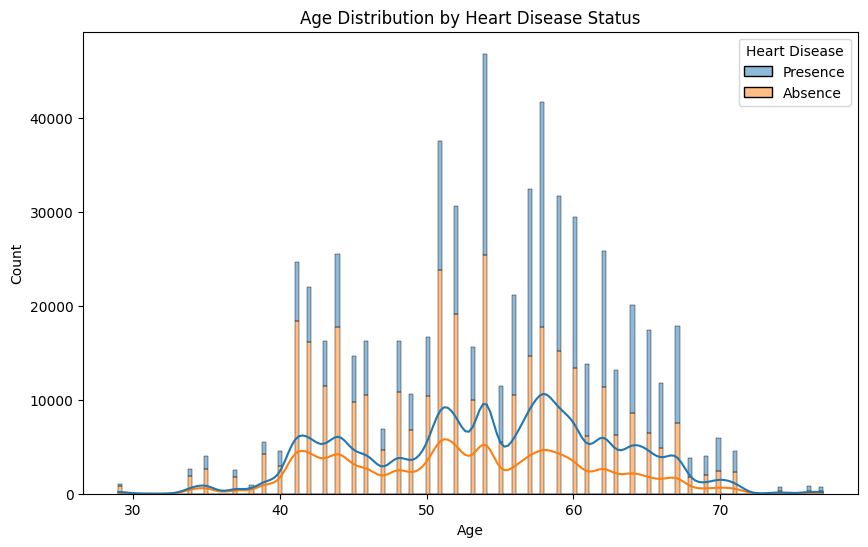

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
train = pd.read_csv('train.csv')

# 2. 基本情報の確認
print("--- Data Info ---")
print(train.info())
print("\n--- Missing Values ---")
print(train.isnull().sum())

# 3. 目的変数（Heart Disease）の分布を可視化
plt.figure(figsize=(6, 4))
sns.countplot(x='Heart Disease', data=train)
plt.title('Distribution of Heart Disease (Target)')
plt.show()

# 4. 数値データ（年齢や血圧など）の相関関係をヒートマップで表示
plt.figure(figsize=(12, 8))
# 数値列のみ抽出して相関を計算
numeric_train = train.select_dtypes(include=[np.number])
sns.heatmap(numeric_train.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 5. 年齢と心臓病の関係をヒストグラムで確認
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='Age', hue='Heart Disease', kde=True, multiple="stack")
plt.title('Age Distribution by Heart Disease Status')
plt.show()